# Classification Examples

Binary classification on the two-moons dataset comparing five UQ approaches:
Deterministic MLP, Ensemble, Repulsive Ensemble, Mean-field VI, and HMC.

Produces the heatmap visualisations used in Figure 5 of the paper.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import shutil

from utils.config import Config
from utils.data import gen_data, create_test_grid
from utils.train import (
    train_mlp,
    train_ensemble,
    train_repulsive_ensemble,
    train_mfvi,
    run_hmc,
    predict_hmc,
)
from utils.plot import plot_res_det, plot_res_sample
from utils.utils import uncertainty_decomposition

In [3]:
FONTSIZE = 18
try:
    if shutil.which("latex") is not None:
        plt.rc("text", usetex=True)
        plt.rc(
            "text.latex",
            preamble=r"\usepackage{amsmath}\usepackage[bitstream-charter]{mathdesign}",
        )
        plt.rc("font", family="serif", size=FONTSIZE, serif="Charter")
    else:
        raise RuntimeError("LaTeX not found")
except Exception:
    plt.rc("text", usetex=False)
    plt.rc("font", family="serif", size=FONTSIZE)

plt.rc("axes", titlesize="medium")

In [4]:
cfg = Config(n_member=10,data_alpha=1.0)
key = jr.PRNGKey(cfg.seed)

data = gen_data(cfg.n_obs, cfg.noise, cfg.seed)
mean, std = data["X"].mean(0), data["X"].std(0)
grid = create_test_grid(cfg.x_lim, cfg.y_lim, cfg.resolution)
norm_grid = (grid - mean) / (std + 1e-6)

## Deterministic MLP

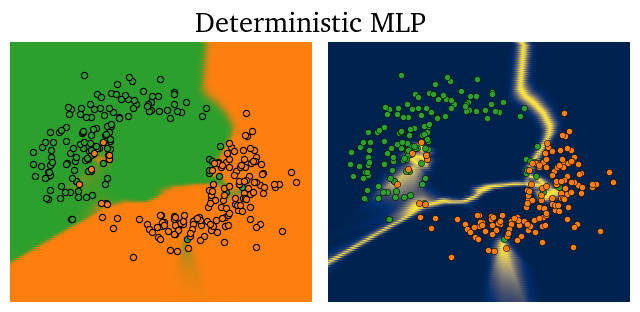

In [5]:
key, subkey = jr.split(key)
det_net = train_mlp(data, cfg.n_steps, subkey, cfg)

logits = jax.vmap(det_net)(norm_grid)
plot_res_det(
    data,
    grid,
    logits,
    x_lim=cfg.x_lim,
    y_lim=cfg.y_lim,
    title="Deterministic MLP",
    data_alpha=cfg.data_alpha,
)
plt.savefig("figures/class_det_mlp.pdf", dpi=300, bbox_inches="tight")

## Ensemble

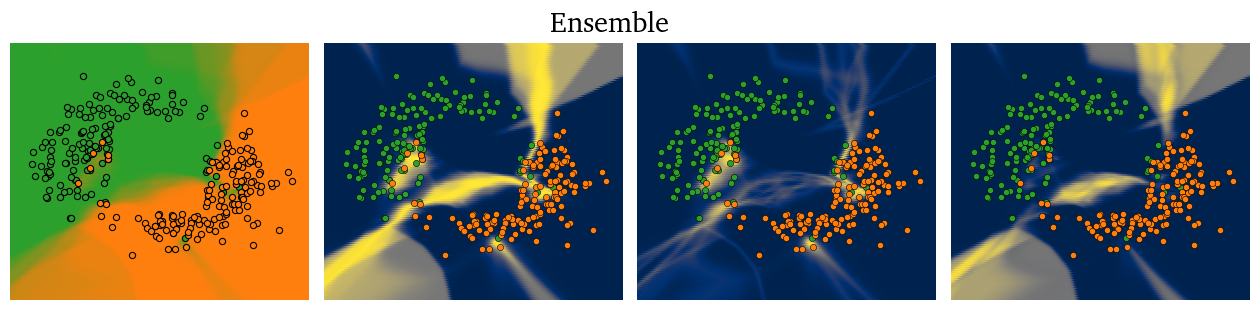

In [6]:
key, subkey = jr.split(key)
ensemble = train_ensemble(data, cfg.n_steps, subkey, cfg, n_member=cfg.n_member)

logits = jax.vmap(ensemble)(norm_grid)
plot_res_sample(
    data,
    grid=grid,
    x_lim=cfg.x_lim,
    y_lim=cfg.y_lim,
    logits=logits,
    title="Ensemble",
    data_alpha=cfg.data_alpha,
)
plt.savefig("figures/class_det_ens.pdf", dpi=300, bbox_inches="tight")

## Repulsive Ensemble

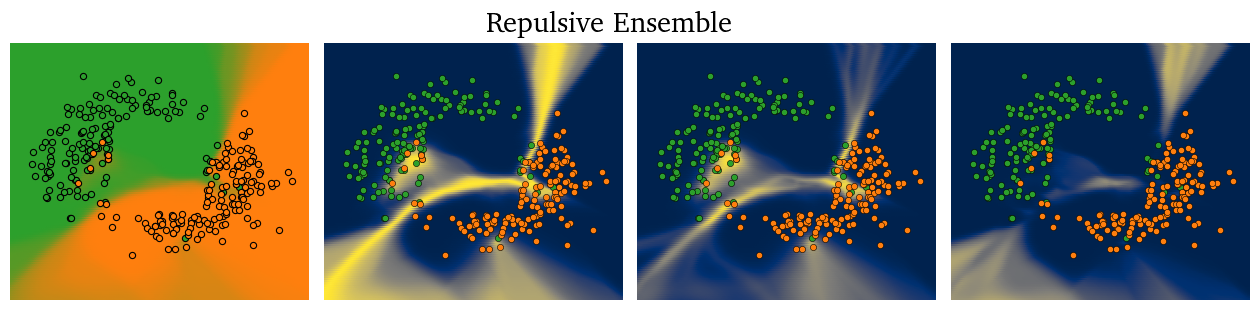

In [7]:
key, subkey = jr.split(key)
rep_ensemble = train_repulsive_ensemble(
    data, cfg.n_steps, subkey, cfg, n_member=cfg.n_member
)

logits = jax.vmap(rep_ensemble)(norm_grid)
plot_res_sample(
    data,
    grid=grid,
    x_lim=cfg.x_lim,
    y_lim=cfg.y_lim,
    logits=logits,
    title="Repulsive Ensemble",
    data_alpha=cfg.data_alpha,
)
plt.savefig("figures/class_det_rep_ens.pdf", dpi=300, bbox_inches="tight")

## Mean-field VI

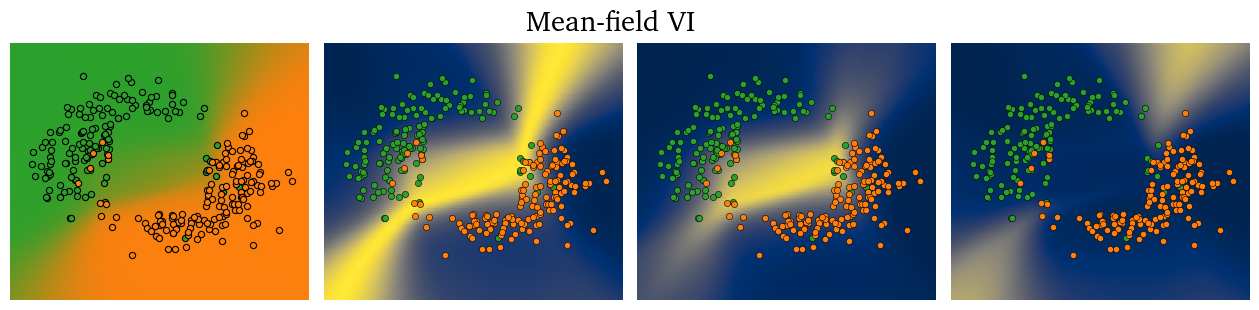

In [8]:
key, subkey = jr.split(key)
vi_model = train_mfvi(data, 2 * cfg.n_steps, subkey, cfg)

vi_keys = jr.split(key, 500)
logits = jax.vmap(
    lambda x: jax.vmap(lambda k: vi_model(x, key=k))(vi_keys),
)(norm_grid)

plot_res_sample(
    data,
    grid=grid,
    x_lim=cfg.x_lim,
    y_lim=cfg.y_lim,
    logits=logits,
    title="Mean-field VI",
    data_alpha=cfg.data_alpha,
)
plt.savefig("figures/class_vi.pdf", dpi=300, bbox_inches="tight")

## HMC

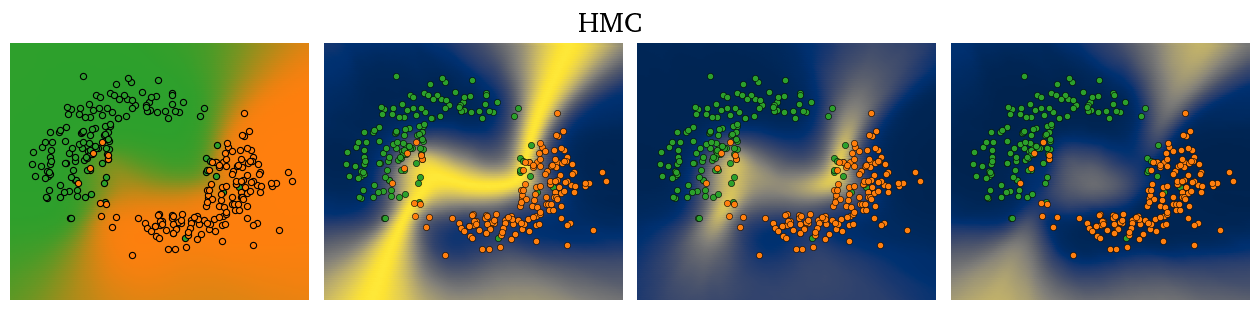

In [9]:
key, subkey = jr.split(key)
hmc_samples, hmc_static = run_hmc(data, subkey, cfg)
hmc_preds = predict_hmc(grid, hmc_samples, hmc_static)

pred_entr, aleatoric, epistemic = uncertainty_decomposition(hmc_preds.T)
res = {
    "probs": hmc_preds.mean(0),
    "total": pred_entr,
    "aleatoric": aleatoric,
    "epistemic": epistemic,
}

plot_res_sample(
    data,
    grid=grid,
    x_lim=cfg.x_lim,
    y_lim=cfg.y_lim,
    decomposed=res,
    title="HMC",
    data_alpha=cfg.data_alpha,
)
plt.savefig("figures/class_hmc.pdf", dpi=300, bbox_inches="tight")